# Laboratório de Validação Independente de IRRBB — Dados Sintéticos

Este notebook foi montado a partir das metodologias e premissas observadas nas imagens do manual de IRRBB enviadas na conversa. Os dados são 100% fictícios. O objetivo é evidenciar riscos de modelo e testar a materialidade de simplificações metodológicas.

Os principais pontos são: CPR, risco de base entre curva de cupom e Pré, depósitos sem vencimento, choque interno, limite de 4%, depósitos à vista, capital próprio, CSRBB e testes de aderência comportamental.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PASTA = Path(".")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


## 1. Carga das bases sintéticas

In [2]:
curva_pre = pd.read_csv(PASTA/"curva_pre_sintetica.csv", parse_dates=["data"])
curva_cupom = pd.read_csv(PASTA/"curva_cupom_sintetica.csv", parse_dates=["data"])
historico_cpr = pd.read_csv(PASTA/"historico_cpr_sintetico.csv", parse_dates=["data"])
depositos_sem_vencimento = pd.read_csv(PASTA/"coortes_depositos_sem_vencimento_sinteticas.csv", parse_dates=["data_coorte"])
depositos_a_vista = pd.read_csv(PASTA/"depositos_a_vista_sinteticos.csv", parse_dates=["data"])
carteira = pd.read_csv(PASTA/"carteira_sintetica.csv")
spreads_csrbb = pd.read_csv(PASTA/"spreads_csrbb_sinteticos.csv", parse_dates=["data"])

display(carteira.head())


,id_instrumento,produto,lado,tipo_taxa,moeda,prazo_anos,nocional,taxa_cupom
0,I0001,Credito_Prefixado,Ativo,Prefixada,BRL,1.000000,"1,089,894.221756",0.118146
1,I0002,Credito_Prefixado,Ativo,Prefixada,BRL,1.000000,"1,861,214.446586",0.150223
2,I0003,Credito_Prefixado,Ativo,Prefixada,BRL,0.500000,"1,878,617.910584",0.167106
3,I0004,Credito_Prefixado,Ativo,Prefixada,BRL,10.000000,"2,025,645.844890",0.137023
4,I0005,Credito_Prefixado,Ativo,Prefixada,BRL,2.000000,"1,734,173.778063",0.103677


## 2. CPR — a janela de 6 meses é estável?

A metodologia apresentada usa os últimos 6 meses para estimar a Taxa de Antecipação Mensal e depois a anualiza para obter a CPR. Este teste compara janelas de 3, 6, 12, 24 e 36 meses.

In [3]:
def cpr_anualizada_da_tam(tam):
    return (1 + tam)**12 - 1

def calcular_cpr_movel(df, janela):
    x = (df.sort_values("data")
           .groupby(["produto","segmento"], group_keys=False)
           .apply(lambda g: g.assign(
               tam_est=g["principal_antecipado"].rolling(janela).sum() /
                       g["saldo_inicial"].rolling(janela).sum()
           )))
    x["cpr_est"] = cpr_anualizada_da_tam(x["tam_est"])
    x["janela"] = janela
    return x

comparacao_janelas = pd.concat([calcular_cpr_movel(historico_cpr, w) for w in [3,6,12,24,36]], ignore_index=True)
ultima_observacao = (comparacao_janelas.dropna()
          .sort_values("data")
          .groupby(["produto","segmento","janela"])
          .tail(1))

tabela_cpr = ultima_observacao.pivot_table(index=["produto","segmento"], columns="janela", values="cpr_est")
tabela_cpr.columns = [f"CPR_{c}m" for c in tabela_cpr.columns]
tabela_cpr["amplitude_pp"] = (tabela_cpr.max(axis=1) - tabela_cpr.min(axis=1))*100
display(tabela_cpr.sort_values("amplitude_pp", ascending=False))


/tmp/ipykernel_827/3565817614.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.assign(
/tmp/ipykernel_827/3565817614.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.assign(
/tmp/ipykernel_827/3565817614.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping col

CPR_3m   CPR_6m  ...  CPR_36m  amplitude_pp
produto         segmento                    ...                       
Credito_Pessoal PF_B     0.258161 0.297892  ... 0.280774      4.958437
Veiculos        PJ       0.170500 0.190352  ... 0.189601      3.810527
                PF_B     0.246464 0.265632  ... 0.228169      3.746353
Credito_Pessoal PJ       0.249596 0.275405  ... 0.241217      3.418858
                PF_A     0.248105 0.272262  ... 0.240189      3.207335
Imobiliario     PF_B     0.099146 0.112036  ... 0.125294      2.783194
                PF_A     0.092322 0.113309  ... 0.116920      2.702145
                PJ       0.071175 0.088085  ... 0.092267      2.109187
Veiculos        PF_A     0.190736 0.192643  ... 0.200529      1.862502

[9 rows x 6 columns]

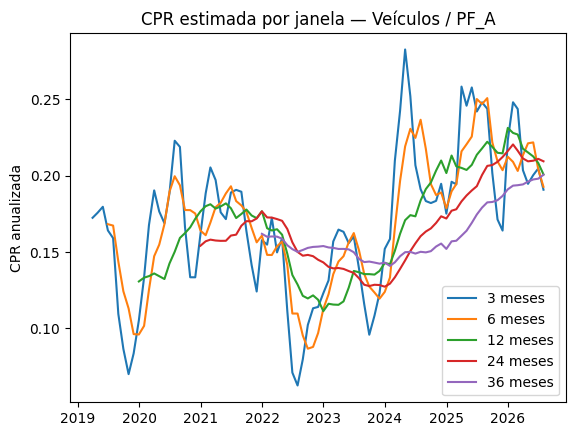

In [4]:
exemplo = comparacao_janelas.query("produto == 'Veiculos' and segmento == 'PF_A'").dropna()
for w in [3,6,12,24,36]:
    s = exemplo[exemplo["janela"]==w]
    plt.plot(s["data"], s["cpr_est"], label=f"{w} meses")
plt.title("CPR estimada por janela — Veículos / PF_A")
plt.ylabel("CPR anualizada")
plt.legend()
plt.show()


### 2.1 CPR por produto versus CPR por segmento

O objetivo é verificar se o uso apenas do código do produto pode ocultar diferenças comportamentais relevantes dentro do mesmo produto.

In [5]:
recente = historico_cpr[historico_cpr["data"] >= historico_cpr["data"].max() - pd.DateOffset(months=12)].copy()
cpr_por_produto = recente.groupby("produto").apply(
    lambda g: cpr_anualizada_da_tam(g["principal_antecipado"].sum()/g["saldo_inicial"].sum())
).rename("cpr_produto")
cpr_por_segmento = recente.groupby(["produto","segmento"]).apply(
    lambda g: cpr_anualizada_da_tam(g["principal_antecipado"].sum()/g["saldo_inicial"].sum())
).rename("cpr_segmento").reset_index()

comparacao_segmentacao = cpr_por_segmento.merge(cpr_por_produto.reset_index(), on="produto")
comparacao_segmentacao["diferenca_pp"] = (comparacao_segmentacao["cpr_segmento"] - comparacao_segmentacao["cpr_produto"])*100
display(comparacao_segmentacao.sort_values("diferenca_pp", key=abs, ascending=False))


/tmp/ipykernel_827/1103766540.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cpr_por_produto = recente.groupby("produto").apply(
/tmp/ipykernel_827/1103766540.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cpr_por_segmento = recente.groupby(["produto","segmento"]).apply(


,produto,segmento,cpr_segmento,cpr_produto,diferenca_pp
1,Credito_Pessoal,PF_B,0.306686,0.273936,3.274986
7,Veiculos,PF_B,0.248263,0.217675,3.058730
0,Credito_Pessoal,PF_A,0.252183,0.273936,-2.175322
5,Imobiliario,PJ,0.087760,0.109220,-2.145978
8,Veiculos,PJ,0.201101,0.217675,-1.657422
4,Imobiliario,PF_B,0.125236,0.109220,1.601630
6,Veiculos,PF_A,0.204797,0.217675,-1.287798
2,Credito_Pessoal,PJ,0.264396,0.273936,-0.954020
3,Imobiliario,PF_A,0.118101,0.109220,0.888069


## 3. Risco de base — o vértice de 252 dias representa toda a curva?

A metodologia usa aproximadamente 1 ano para estimar a relação entre a curva de cupom e a curva Pré. O teste calcula essa relação em vários prazos.

In [6]:
risco_base = curva_cupom.merge(curva_pre, on=["data","prazo_anos"])
risco_base["relacao_cupom_pre"] = risco_base["taxa_cupom"] / risco_base["taxa_pre"]

q = risco_base.groupby("prazo_anos")["relacao_cupom_pre"].quantile([0.01,0.99]).unstack()
q.columns = ["P1","P99"]
q["choque_referencia"] = q.abs().max(axis=1)
q["choque_1_ano"] = q.loc[1.0,"choque_referencia"]
q["erro_relativo_vs_1_ano"] = q["choque_1_ano"]/q["choque_referencia"] - 1
display(q)


,P1,P99,choque_referencia,choque_1_ano,erro_relativo_vs_1_ano
prazo_anos,,,,,
0.250000,1.024180,1.083573,1.083573,1.061046,-0.020789
0.500000,1.021082,1.069176,1.069176,1.061046,-0.007605
1.000000,1.013284,1.061046,1.061046,1.061046,0.000000
2.000000,1.006530,1.050920,1.050920,1.061046,0.009635
5.000000,0.990522,1.028679,1.028679,1.061046,0.031464
7.000000,0.990172,1.024339,1.024339,1.061046,0.035835
10.000000,0.986939,1.015615,1.015615,1.061046,0.044732
15.000000,0.979545,1.014208,1.014208,1.061046,0.046181
20.000000,0.974505,1.007654,1.007654,1.061046,0.052986


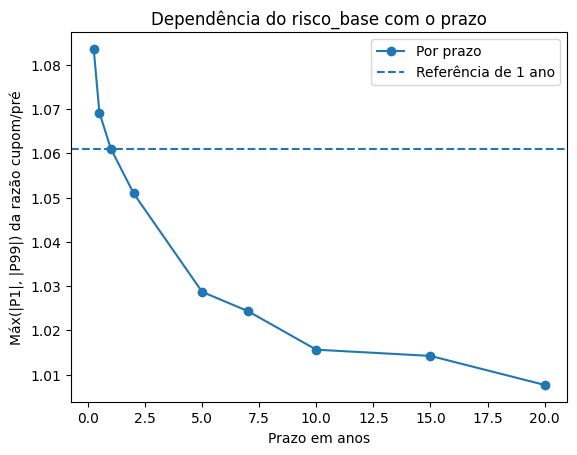

In [7]:
plt.plot(q.index, q["choque_referencia"], marker="o", label="Por prazo")
plt.axhline(q.loc[1.0,"choque_referencia"], linestyle="--", label="Referência de 1 ano")
plt.xlabel("Prazo em anos")
plt.ylabel("Máx(|P1|, |P99|) da razão cupom/pré")
plt.title("Dependência do risco_base com o prazo")
plt.legend()
plt.show()


## 4. Depósitos sem vencimento — estabilidade temporal

O teste usa a meia-vida observada de cada coorte como medida simples de estabilidade comportamental.

In [8]:
def meia_vida_observada(g):
    g = g.sort_values("dia")
    idx = (g["percentual_sobrevivencia"] - 0.5).abs().idxmin()
    return g.loc[idx, "dia"]

meias_vidas = (depositos_sem_vencimento.groupby(["data_coorte","segmento"])
        .apply(meia_vida_observada)
        .rename("meia_vida_dias")
        .reset_index())

display(meias_vidas.groupby("segmento")["meia_vida_dias"].agg(media="mean", desvio_padrao="std", minimo="min", maximo="max"))


/tmp/ipykernel_827/2034733819.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(meia_vida_observada)


,media,desvio_padrao,minimo,maximo
segmento,,,,
Atacado,155.750000,21.377050,126,189
Varejo_Estavel,763.000000,105.212828,588,945
Varejo_Nao_Estavel,308.875000,40.360670,252,378


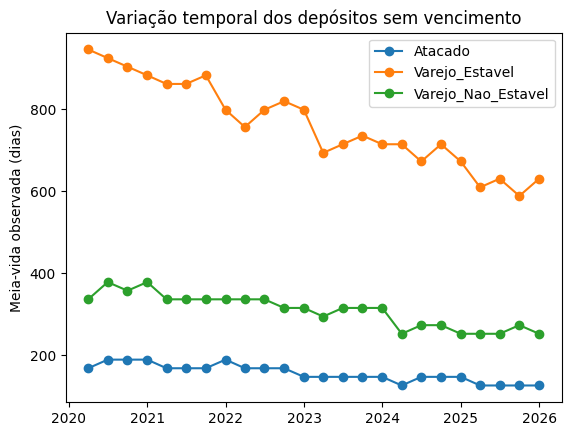

In [9]:
for seg in meias_vidas["segmento"].unique():
    s = meias_vidas[meias_vidas["segmento"]==seg]
    plt.plot(s["data_coorte"], s["meia_vida_dias"], marker="o", label=seg)
plt.ylabel("Meia-vida observada (dias)")
plt.title("Variação temporal dos depósitos sem vencimento")
plt.legend()
plt.show()


## 5. Choque interno — média simples entre vértices pode diluir extremos

Criamos uma estrutura de choque por prazo e uma sensibilidade concentrada no curto prazo para comparar média simples, máximo e média ponderada por DV01.

In [10]:
vertices = pd.DataFrame({
    "prazo_anos":[0.25,0.5,1,2,5,7,10,15,20],
    "choque":[0.105,0.080,0.055,0.040,0.030,0.025,0.022,0.020,0.018],
    "dv01":[40,35,30,25,15,8,5,2,1]
})

media_simples = vertices["choque"].mean()
choque_maximo = vertices["choque"].max()
media_ponderada_dv01 = np.average(vertices["choque"], weights=vertices["dv01"])

comparacao_choque = pd.DataFrame({
    "metodo":["Média simples","Máximo","Média ponderada por DV01"],
    "choque":[media_simples,choque_maximo,media_ponderada_dv01]
})
display(comparacao_choque)


,metodo,choque
0,Média simples,0.043889
1,Máximo,0.105000
2,Média ponderada por DV01,0.065019


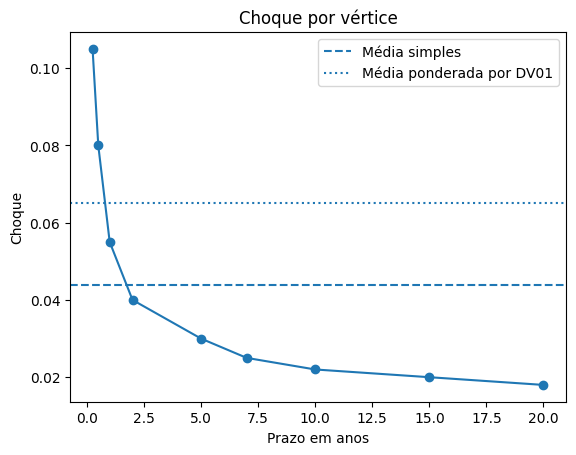

In [11]:
plt.plot(vertices["prazo_anos"], vertices["choque"], marker="o")
plt.axhline(media_simples, linestyle="--", label="Média simples")
plt.axhline(media_ponderada_dv01, linestyle=":", label="Média ponderada por DV01")
plt.xlabel("Prazo em anos")
plt.ylabel("Choque")
plt.title("Choque por vértice")
plt.legend()
plt.show()


### 5.1 Limite de 4%

Este teste mede com que frequência o limite de 4% se torna ativo e quanto ele reduz o choque médio.

In [12]:
choques_sem_limite = pd.Series(np.random.default_rng(123).lognormal(mean=np.log(0.032), sigma=0.40, size=120), name="choque_sem_limite")
limite = 0.04
choques_limitados = choques_sem_limite.clip(upper=limite)

estatisticas_limite = pd.Series({
    "média_sem_limite":choques_sem_limite.mean(),
    "média_com_limite":choques_limitados.mean(),
    "percentual_meses_limite_ativo":(choques_sem_limite>limite).mean(),
    "máximo_sem_limite":choques_sem_limite.max(),
    "redução_média_relativa":1-choques_limitados.mean()/choques_sem_limite.mean()
})
display(estatisticas_limite.to_frame("valor"))


,valor
média_sem_limite,0.035467
média_com_limite,0.031457
percentual_meses_limite_ativo,0.308333
máximo_sem_limite,0.079974
redução_média_relativa,0.113064


## 6. Depósitos à vista — máximo histórico versus percentis

O uso da maior redução histórica pode ser excessivamente sensível a um único mês extremo. Comparamos máximo, P95, P99 e média da cauda acima do P95.

In [13]:
saidas = depositos_a_vista.assign(saida=(-depositos_a_vista["variacao_mensal"]).clip(lower=0))
linhas = []
for cooperativa,g in saidas.groupby("cooperativa"):
    valores = g["saida"].values
    p95 = np.quantile(valores,0.95)
    p99 = np.quantile(valores,0.99)
    es95 = valores[valores>=p95].mean()
    linhas.append([cooperativa, valores.max(), p95, p99, es95])
estatisticas_depositos = pd.DataFrame(linhas, columns=["cooperativa","maximo","p95","p99","media_cauda_95"])
estatisticas_depositos["diferenca_maximo_p99_pp"] = (estatisticas_depositos["maximo"]-estatisticas_depositos["p99"])*100
display(estatisticas_depositos.sort_values("diferenca_maximo_p99_pp", ascending=False))


,cooperativa,maximo,p95,p99,media_cauda_95,diferenca_maximo_p99_pp
3,Coop_04,0.253071,0.086058,0.176787,0.154906,7.628444
0,Coop_01,0.197996,0.063384,0.131836,0.114798,6.615942
4,Coop_05,0.219467,0.058938,0.166399,0.127605,5.306708
8,Coop_09,0.250712,0.052521,0.216155,0.149393,3.455761
6,Coop_07,0.203941,0.060108,0.181712,0.130548,2.222885
1,Coop_02,0.262831,0.057898,0.242003,0.155766,2.082791
9,Coop_10,0.275358,0.059236,0.258578,0.174508,1.678040
7,Coop_08,0.281493,0.082294,0.266059,0.178741,1.543371
5,Coop_06,0.232586,0.057112,0.218525,0.149922,1.406070
2,Coop_03,0.192490,0.059569,0.189324,0.129079,0.316601


## 7. Capital próprio — sensibilidade à alocação em 6, 12, 18 e 24 meses

A alocação uniforme em quatro vértices é uma premissa de modelagem. O teste compara perfis alternativos.

In [14]:
def valor_presente_fluxos(valor_pl, pesos, prazos, taxa_base=0.10, choque=0.03):
    vp_base = sum(valor_pl*w/((1+taxa_base)**t) for w,t in zip(pesos,prazos))
    vp_estresse = sum(valor_pl*w/((1+taxa_base+choque)**t) for w,t in zip(pesos,prazos))
    return vp_base, vp_estresse, vp_base-vp_estresse

valor_pl = 500_000_000
cenarios_pl = {
    "Uniforme 6/12/18/24m":([0.25]*4,[0.5,1,1.5,2]),
    "Mais curto":([0.55,0.25,0.15,0.05],[0.5,1,1.5,2]),
    "Mais longo":([0.05,0.15,0.30,0.50],[0.5,1,1.5,2]),
    "Tudo 1 ano":([1.0],[1.0]),
    "Sem PL":([0.0],[1.0])
}
resultado=[]
for nome,(pesos,prazos) in cenarios_pl.items():
    vp_base,vp_estresse,delta_eve = valor_presente_fluxos(valor_pl,pesos,prazos)
    resultado.append([nome,vp_base,vp_estresse,delta_eve])
sensibilidade_pl = pd.DataFrame(resultado,columns=["cenario","vp_base","vp_estresse","delta_eve"])
display(sensibilidade_pl)


,cenario,vp_base,vp_estresse,delta_eve
0,Uniforme 6/12/18/24m,"444,472,993.921211","430,164,955.959010","14,308,037.962200"
1,Mais curto,"461,508,545.606803","451,333,600.694055","10,174,944.912748"
2,Mais longo,"428,647,578.967109","410,550,825.524313","18,096,753.442796"
3,Tudo 1 ano,"454,545,454.545455","442,477,876.106195","12,067,578.439260"
4,Sem PL,0.000000,0.000000,0.000000


## 8. CSRBB — dependência de um único episódio histórico

Comparamos o pior aumento de spread em 21 dias da amostra completa com o pior episódio posterior a 2021.

In [15]:
csrbb_1_ano = spreads_csrbb[spreads_csrbb["prazo_anos"]==1].pivot(index="data",columns="grupo_emissor",values="spread").sort_index()
variacao_21_dias = csrbb_1_ano.pct_change(21)

resumo_csrbb=[]
for cl in variacao_21_dias.columns:
    s=variacao_21_dias[cl].dropna()
    data_pior=s.idxmax()
    pior=s.max()
    pior_pos_2021=s[s.index>=pd.Timestamp("2021-01-01")].max()
    resumo_csrbb.append([cl,data_pior,pior,pior_pos_2021,pior-pior_pos_2021])
resumo_csrbb=pd.DataFrame(resumo_csrbb,columns=["grupo_emissor","data_pior","pior_21_dias","pior_pos_2021","diferenca"])
display(resumo_csrbb)


,grupo_emissor,data_pior,pior_21_dias,pior_pos_2021,diferenca
0,Bancos_S1,2020-04-06,1.965651,0.793982,1.171669
1,Demais,2025-05-28,1.020217,1.020217,0.000000
2,Internacional,2020-04-07,0.799236,0.310385,0.488851
3,Qualitativo,2020-04-08,0.738635,0.411798,0.326837
4,Veiculos,2020-04-08,1.122945,0.363928,0.759017


## 9. Teste de aderência comportamental

O teste de aderência dos choques de juros não substitui a validação das premissas comportamentais. Aqui avaliamos erro de previsão da CPR e da meia-vida dos depósitos.

In [16]:
# CPR: previsão simples com média móvel 6m versus realizado
cpr_teste = historico_cpr.sort_values("data").copy()
cpr_teste["tam_prevista_6m"] = (
    cpr_teste.groupby(["produto","segmento"])["tam_realizada"]
          .transform(lambda s: s.shift(1).rolling(6).mean())
)
cpr_teste["erro"] = cpr_teste["tam_realizada"] - cpr_teste["tam_prevista_6m"]

metricas_cpr = (cpr_teste.dropna()
               .groupby(["produto","segmento"])["erro"]
               .agg(erro_absoluto_medio=lambda s: np.mean(np.abs(s)),
                    vies="mean",
                    raiz_erro_quadratico_medio=lambda s: np.sqrt(np.mean(s**2))))
display(metricas_cpr)


erro_absoluto_medio  ...  raiz_erro_quadratico_medio
produto         segmento                       ...                            
Credito_Pessoal PF_A                 0.002992  ...                    0.004039
                PF_B                 0.002543  ...                    0.003250
                PJ                   0.002704  ...                    0.003461
Imobiliario     PF_A                 0.002935  ...                    0.003567
                PF_B                 0.002747  ...                    0.003427
                PJ                   0.002411  ...                    0.003051
Veiculos        PF_A                 0.003171  ...                    0.004057
                PF_B                 0.002791  ...                    0.003475
                PJ                   0.002993  ...                    0.003823

[9 rows x 3 columns]

In [17]:
# Depositos_Sem_Vencimento: compara meia-vida da coorte com a mediana histórica anterior
meias_vidas = meias_vidas.sort_values("data_coorte")
meias_vidas["meia_vida_prevista"] = (
    meias_vidas.groupby("segmento")["meia_vida_dias"]
        .transform(lambda s: s.shift(1).expanding(min_periods=4).median())
)
meias_vidas["erro_dias"] = meias_vidas["meia_vida_dias"] - meias_vidas["meia_vida_prevista"]

metricas_depositos=(meias_vidas.dropna()
             .groupby("segmento")["erro_dias"]
             .agg(erro_absoluto_medio=lambda s: np.mean(np.abs(s)),
                  vies="mean",
                  raiz_erro_quadratico_medio=lambda s: np.sqrt(np.mean(s**2))))
display(metricas_depositos)


,erro_absoluto_medio,vies,raiz_erro_quadratico_medio
segmento,,,
Atacado,21.525000,-19.425000,24.286570
Varejo_Estavel,107.100000,-107.100000,117.581249
Varejo_Nao_Estavel,37.275000,-37.275000,46.188067


## 10. Quadro-resumo de potenciais pontos de atenção

As faixas de criticidade são apenas ilustrativas e servem para transformar os testes em sinais objetivos de risco de modelo.

In [18]:
quadro_resumo = []

# CPR instability
maior_amplitude_cpr = float(tabela_cpr["amplitude_pp"].max())
quadro_resumo.append(["CPR - janela de estimação", maior_amplitude_cpr, "pp de faixa entre janelas",
                  "ALTO" if maior_amplitude_cpr>5 else "MÉDIO" if maior_amplitude_cpr>2 else "BAIXO"])

# Basis
maior_erro_risco_base = float(q["erro_relativo_vs_1_ano"].abs().max()*100)
quadro_resumo.append(["Risco de base - referência de 1 ano", maior_erro_risco_base, "% erro relativo vs estrutura a termo",
                  "ALTO" if maior_erro_risco_base>15 else "MÉDIO" if maior_erro_risco_base>7 else "BAIXO"])

# Depositos_Sem_Vencimento drift
dispersao_nmd = float(meias_vidas.groupby("segmento")["meia_vida_dias"].mean().std())
quadro_resumo.append(["Depósitos sem vencimento - estabilidade temporal", dispersao_nmd, "dispersão entre segmentos/coortes",
                  "ALTO" if dispersao_nmd>100 else "MÉDIO"])

# Shock averaging
diluicao = float((media_ponderada_dv01-media_simples)*100)
quadro_resumo.append(["Choque interno - média simples", diluicao, "p.p. versus ponderação por DV01",
                  "ALTO" if abs(diluicao)>1 else "MÉDIO"])

# Cap
percentual_limite_ativo = float((choques_sem_limite>limite).mean()*100)
quadro_resumo.append(["Choque interno - limite de 4%", percentual_limite_ativo, "% de meses com limite ativo",
                  "ALTO" if percentual_limite_ativo>25 else "MÉDIO" if percentual_limite_ativo>10 else "BAIXO"])

# DD max
maior_gap_depositos = float(estatisticas_depositos["diferenca_maximo_p99_pp"].max())
quadro_resumo.append(["Depósitos à vista - máximo histórico", maior_gap_depositos, "p.p. entre máximo e P99",
                  "ALTO" if maior_gap_depositos>5 else "MÉDIO"])

# Capital
amplitude_pl = float((sensibilidade_pl["delta_eve"].max()-sensibilidade_pl["delta_eve"].min())/1e6)
quadro_resumo.append(["Capital próprio - alocação", amplitude_pl, "R$ milhões de amplitude em ΔEVE",
                  "ALTO" if amplitude_pl>10 else "MÉDIO"])

quadro_resumo = pd.DataFrame(quadro_resumo, columns=["tema","indicador","unidade","criticidade"])
display(quadro_resumo)


,tema,indicador,unidade,criticidade
0,CPR - janela de estimação,4.958437,pp de faixa entre janelas,MÉDIO
1,Risco de base - referência de 1 ano,5.298632,% erro relativo vs estrutura a termo,BAIXO
2,Depósitos sem vencimento - estabilidade temporal,315.813591,dispersão entre segmentos/coortes,ALTO
3,Choque interno - média simples,2.112974,p.p. versus ponderação por DV01,ALTO
4,Choque interno - limite de 4%,30.833333,% de meses com limite ativo,ALTO
5,Depósitos à vista - máximo histórico,7.628444,p.p. entre máximo e P99,ALTO
6,Capital próprio - alocação,18.096753,R$ milhões de amplitude em ΔEVE,ALTO


## 11. Interpretação

O laboratório não conclui automaticamente que a metodologia está errada. Um ponto ganha relevância quando uma alternativa plausível produz impacto material, quando a premissa é instável, quando não há teste de aderência específico ou quando a simplificação reduz sistematicamente a medida de risco.